In [2]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    label_binarize,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET_COLUMN = "NObeyesdad"

print("Environment setup completed successfully.")

Environment setup completed successfully.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic.csv


In [4]:
file_name = "ObesityDataSet_raw_and_data_sinthetic.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
# Display basic dataset information
print("DATASET INFORMATION")
print("=" * 50)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF           

In [6]:
# Check data quality
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Missing values in each column
df.isnull().sum()

Missing values: 0
Duplicate rows: 24


,0
Age,0
Gender,0
Height,0
Weight,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0
SMOKE,0


In [7]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


In [8]:
print("Number of obesity classes:", df["NObeyesdad"].nunique())
print("\nObesity classes:")

print(df["NObeyesdad"].value_counts())

Number of obesity classes: 7

Obesity classes:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [9]:
# Create a copy of the original dataset
df_clean = df.copy()

# Remove exact duplicate rows
rows_before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
rows_after = df_clean.shape[0]

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicates removed:", rows_before - rows_after)
print("Remaining duplicates:", df_clean.duplicated().sum())

Rows before removing duplicates: 2111
Rows after removing duplicates: 2087
Duplicates removed: 24
Remaining duplicates: 0


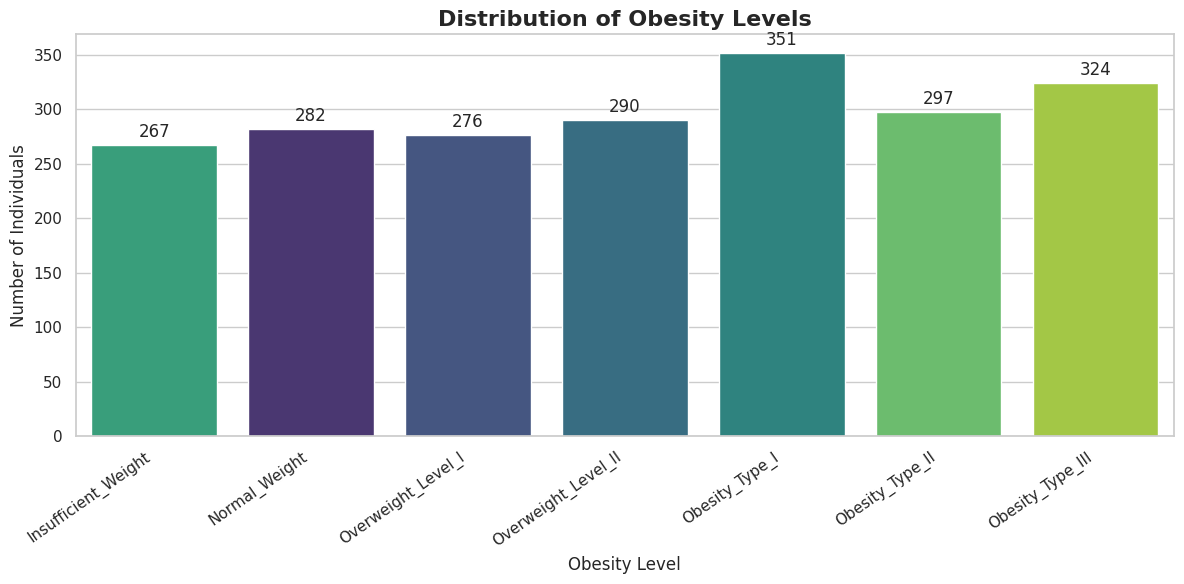

In [10]:
# Define the correct order of obesity classes
class_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_clean,
    x="NObeyesdad",
    order=class_order,
    hue="NObeyesdad",
    palette="viridis",
    legend=False
)

# Display count above each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title(
    "Distribution of Obesity Levels",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Obesity Level", fontsize=12)
plt.ylabel("Number of Individuals", fontsize=12)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Target column
target_column = "NObeyesdad"

# Separate numerical and categorical feature names
numerical_features = df_clean.drop(columns=[target_column]).select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df_clean.drop(columns=[target_column]).select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Categorical features:
['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']

Number of numerical features: 8
Number of categorical features: 8


In [12]:
# Display unique values in each categorical feature
for column in categorical_features:
    print(f"\n{column}:")
    print(df_clean[column].value_counts())


Gender:
Gender
Male      1052
Female    1035
Name: count, dtype: int64

CALC:
CALC
Sometimes     1380
no             636
Frequently      70
Always           1
Name: count, dtype: int64

FAVC:
FAVC
yes    1844
no      243
Name: count, dtype: int64

SCC:
SCC
no     1991
yes      96
Name: count, dtype: int64

SMOKE:
SMOKE
no     2043
yes      44
Name: count, dtype: int64

family_history_with_overweight:
family_history_with_overweight
yes    1722
no      365
Name: count, dtype: int64

CAEC:
CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64

MTRANS:
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64


In [13]:
# Create BMI for exploratory analysis
df_clean["BMI"] = (
    df_clean["Weight"] / (df_clean["Height"] ** 2)
).round(2)

df_clean[["Height", "Weight", "BMI", "NObeyesdad"]].head()

,Height,Weight,BMI,NObeyesdad
0,1.62,64.0,24.39,Normal_Weight
1,1.52,56.0,24.24,Normal_Weight
2,1.80,77.0,23.77,Normal_Weight
3,1.80,87.0,26.85,Overweight_Level_I
4,1.78,89.8,28.34,Overweight_Level_II


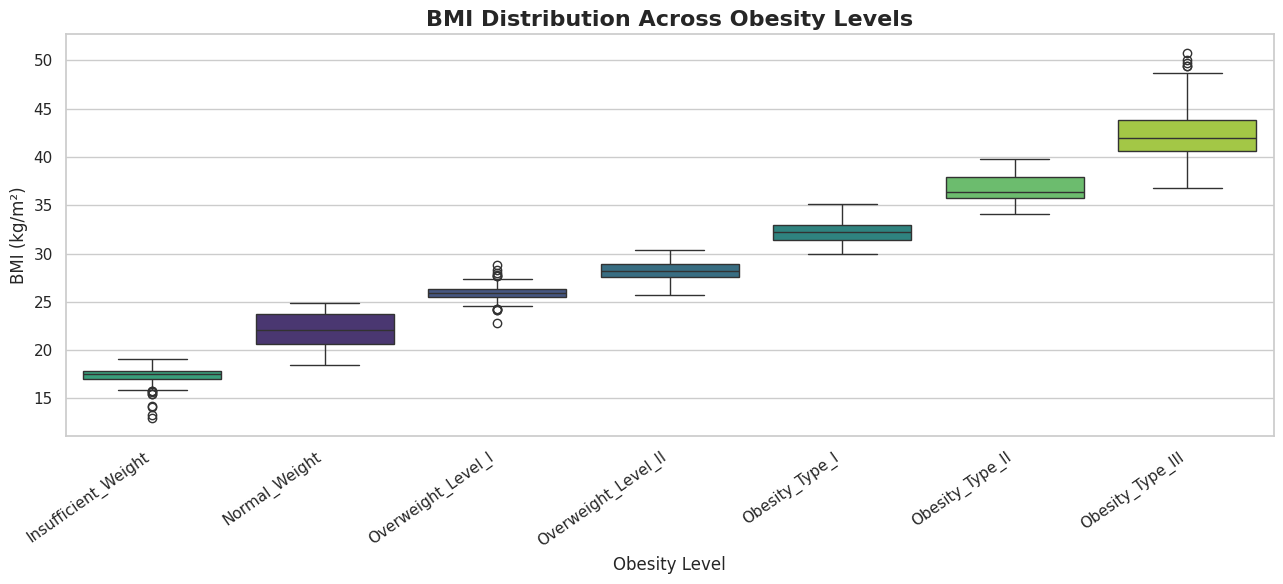

In [14]:
plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df_clean,
    x="NObeyesdad",
    y="BMI",
    order=class_order,
    hue="NObeyesdad",
    palette="viridis",
    legend=False
)

plt.title(
    "BMI Distribution Across Obesity Levels",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Obesity Level", fontsize=12)
plt.ylabel("BMI (kg/m²)", fontsize=12)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [15]:
# Create a fresh modelling dataset
proposal_df = df_clean.copy()

# Remove the previously created BMI column
if "BMI" in proposal_df.columns:
    proposal_df = proposal_df.drop(columns=["BMI"])

print("Dataset shape:", proposal_df.shape)
print("Duplicate rows:", proposal_df.duplicated().sum())
print("Missing values:", proposal_df.isnull().sum().sum())

Dataset shape: (2087, 17)
Duplicate rows: 0
Missing values: 0


In [16]:
# Calculate BMI
proposal_df["BMI"] = (
    proposal_df["Weight"] /
    (proposal_df["Height"] ** 2)
)

# Create WHO BMI category
def calculate_who_bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    elif bmi < 35:
        return "Obesity_Class_I"
    elif bmi < 40:
        return "Obesity_Class_II"
    else:
        return "Obesity_Class_III"

proposal_df["WHO_BMI_Category"] = (
    proposal_df["BMI"].apply(calculate_who_bmi_category)
)

# Create composite physical activity score
# Higher FAF increases the score; higher TUE reduces the score
proposal_df["Physical_Activity_Score"] = (
    proposal_df["FAF"] - proposal_df["TUE"]
)

proposal_df[
    [
        "Height",
        "Weight",
        "BMI",
        "WHO_BMI_Category",
        "FAF",
        "TUE",
        "Physical_Activity_Score",
        "NObeyesdad"
    ]
].head()

,Height,Weight,BMI,WHO_BMI_Category,FAF,TUE,Physical_Activity_Score,NObeyesdad
0,1.62,64.0,24.386526,Normal,0.0,1.0,-1.0,Normal_Weight
1,1.52,56.0,24.238227,Normal,3.0,0.0,3.0,Normal_Weight
2,1.80,77.0,23.765432,Normal,2.0,1.0,1.0,Normal_Weight
3,1.80,87.0,26.851852,Overweight,2.0,0.0,2.0,Overweight_Level_I
4,1.78,89.8,28.342381,Overweight,0.0,0.0,0.0,Overweight_Level_II


In [17]:
print("Derived features created successfully!")
print(
    "BMI range:",
    round(proposal_df["BMI"].min(), 2),
    "to",
    round(proposal_df["BMI"].max(), 2)
)

print("\nWHO BMI category distribution:")
print(
    proposal_df["WHO_BMI_Category"].value_counts()
)

print("\nImportant:")
print(
    "BMI and WHO_BMI_Category will be excluded "
    "from primary model training to prevent target leakage."
)

Derived features created successfully!
BMI range: 13.0 to 50.81

WHO BMI category distribution:
WHO_BMI_Category
Overweight           552
Obesity_Class_I      368
Obesity_Class_II     338
Normal               295
Obesity_Class_III    268
Underweight          266
Name: count, dtype: int64

Important:
BMI and WHO_BMI_Category will be excluded from primary model training to prevent target leakage.


In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

class IQRClipper(BaseEstimator, TransformerMixin):
    """
    Learns IQR limits from training data only
    and clips values using 3 × IQR boundaries.
    """

    def __init__(self, factor=3.0):
        self.factor = factor

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        self.q1_ = np.nanpercentile(X, 25, axis=0)
        self.q3_ = np.nanpercentile(X, 75, axis=0)

        self.iqr_ = self.q3_ - self.q1_

        self.lower_bounds_ = (
            self.q1_ - self.factor * self.iqr_
        )

        self.upper_bounds_ = (
            self.q3_ + self.factor * self.iqr_
        )

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        return np.clip(
            X,
            self.lower_bounds_,
            self.upper_bounds_
        )

print("IQRClipper created successfully!")

IQRClipper created successfully!


In [19]:
# Exclude target and leakage-prone derived features
X_proposal = proposal_df.drop(
    columns=[
        "NObeyesdad",
        "BMI",
        "WHO_BMI_Category"
    ]
)

y_proposal = proposal_df["NObeyesdad"]

print("Primary input shape:", X_proposal.shape)
print("Target shape:", y_proposal.shape)
print("\nPrimary model features:")
print(X_proposal.columns.tolist())

Primary input shape: (2087, 17)
Target shape: (2087,)

Primary model features:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'Physical_Activity_Score']


In [20]:
continuous_columns = [
    "Age",
    "Height",
    "Weight",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
    "Physical_Activity_Score"
]

ordinal_numeric_columns = [
    "FCVC"
]

binary_categorical_columns = [
    "Gender",
    "FAVC",
    "SCC",
    "SMOKE",
    "family_history_with_overweight"
]

nominal_categorical_columns = [
    "CALC",
    "CAEC",
    "MTRANS"
]

all_defined_columns = (
    continuous_columns +
    ordinal_numeric_columns +
    binary_categorical_columns +
    nominal_categorical_columns
)

print("Defined feature count:", len(all_defined_columns))
print(
    "All input columns covered:",
    set(all_defined_columns) == set(X_proposal.columns)
)

Defined feature count: 17
All input columns covered: True


In [21]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Continuous: median imputation, IQR clipping and scaling
continuous_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "iqr_clipper",
            IQRClipper(factor=3.0)
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Ordinal numerical: median imputation and scaling
ordinal_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Binary categorical: mode imputation and ordinal encoding
binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

# Multi-class nominal: mode imputation and one-hot encoding
nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

proposal_preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_pipeline,
            continuous_columns
        ),
        (
            "ordinal_numeric",
            ordinal_numeric_pipeline,
            ordinal_numeric_columns
        ),
        (
            "binary",
            binary_pipeline,
            binary_categorical_columns
        ),
        (
            "nominal",
            nominal_pipeline,
            nominal_categorical_columns
        )
    ]
)

print("Proposal-aligned preprocessing pipeline created!")

Proposal-aligned preprocessing pipeline created!


In [22]:
X_train_proposal, X_test_proposal, \
y_train_proposal, y_test_proposal = train_test_split(
    X_proposal,
    y_proposal,
    test_size=0.20,
    random_state=42,
    stratify=y_proposal
)

print("Training shape:", X_train_proposal.shape)
print("Testing shape:", X_test_proposal.shape)

print(
    "Training missing values:",
    X_train_proposal.isnull().sum().sum()
)

print(
    "Testing missing values:",
    X_test_proposal.isnull().sum().sum()
)

Training shape: (1669, 17)
Testing shape: (418, 17)
Training missing values: 0
Testing missing values: 0


In [23]:
proposal_random_forest = RandomForestClassifier(
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

proposal_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            proposal_preprocessor
        ),
        (
            "classifier",
            proposal_random_forest
        )
    ]
)

print("Corrected Random Forest pipeline created!")

Corrected Random Forest pipeline created!


In [24]:
proposal_parameter_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2]
}

proposal_stratified_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

proposal_grid_search = GridSearchCV(
    estimator=proposal_rf_pipeline,
    param_grid=proposal_parameter_grid,
    scoring="f1_macro",
    cv=proposal_stratified_cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Proposal-aligned GridSearchCV created!")

Proposal-aligned GridSearchCV created!


In [25]:
print("Proposal-aligned GridSearchCV started...")

proposal_grid_search.fit(
    X_train_proposal,
    y_train_proposal
)

print("Proposal-aligned GridSearchCV completed!")

Proposal-aligned GridSearchCV started...
Fitting 10 folds for each of 36 candidates, totalling 360 fits
Proposal-aligned GridSearchCV completed!


In [26]:
print("Best parameters:")
print(proposal_grid_search.best_params_)

print(
    "\nBest cross-validation Macro F1-score:",
    round(proposal_grid_search.best_score_, 4)
)

Best parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

Best cross-validation Macro F1-score: 0.9443


In [27]:
proposal_best_model = (
    proposal_grid_search.best_estimator_
)

proposal_y_pred = proposal_best_model.predict(
    X_test_proposal
)

proposal_accuracy = accuracy_score(
    y_test_proposal,
    proposal_y_pred
)

proposal_precision = precision_score(
    y_test_proposal,
    proposal_y_pred,
    average="macro"
)

proposal_recall = recall_score(
    y_test_proposal,
    proposal_y_pred,
    average="macro"
)

proposal_f1 = f1_score(
    y_test_proposal,
    proposal_y_pred,
    average="macro"
)

print("PROPOSAL-ALIGNED RANDOM FOREST PERFORMANCE")
print("=" * 55)
print(f"Accuracy        : {proposal_accuracy:.4f}")
print(f"Macro Precision : {proposal_precision:.4f}")
print(f"Macro Recall    : {proposal_recall:.4f}")
print(f"Macro F1-Score  : {proposal_f1:.4f}")

print("\nCLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_test_proposal,
        proposal_y_pred,
        digits=4
    )
)

PROPOSAL-ALIGNED RANDOM FOREST PERFORMANCE
Accuracy        : 0.9426
Macro Precision : 0.9459
Macro Recall    : 0.9405
Macro F1-Score  : 0.9415

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

Insufficient_Weight     1.0000    0.9434    0.9709        53
      Normal_Weight     0.7714    0.9474    0.8504        57
     Obesity_Type_I     1.0000    0.9571    0.9781        70
    Obesity_Type_II     1.0000    1.0000    1.0000        60
   Obesity_Type_III     1.0000    0.9846    0.9922        65
 Overweight_Level_I     0.9216    0.8545    0.8868        55
Overweight_Level_II     0.9286    0.8966    0.9123        58

           accuracy                         0.9426       418
          macro avg     0.9459    0.9405    0.9415       418
       weighted avg     0.9486    0.9426    0.9440       418



In [28]:
from sklearn.preprocessing import FunctionTransformer

# Calculate IQR limits using training data only
continuous_training_data = (
    X_train_proposal[continuous_columns]
)

q1 = continuous_training_data.quantile(0.25)
q3 = continuous_training_data.quantile(0.75)
iqr = q3 - q1

lower_iqr_bounds = (
    q1 - 3.0 * iqr
).to_numpy()

upper_iqr_bounds = (
    q3 + 3.0 * iqr
).to_numpy()

iqr_limits_table = pd.DataFrame({
    "Feature": continuous_columns,
    "Lower Limit": lower_iqr_bounds,
    "Upper Limit": upper_iqr_bounds
})

iqr_limits_table.round(4)

,Feature,Lower Limit,Upper Limit
0,Age,1.4636,44.4023
1,Height,1.2135,2.1853
2,Weight,-63.6236,236.7953
3,NCP,1.7189,3.9608
4,CH2O,-1.0730,5.0945
5,FAF,-4.4687,6.2648
6,TUE,-3.0000,4.0000
7,Physical_Activity_Score,-4.2814,4.9610


In [29]:
portable_continuous_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "iqr_clipper",
            FunctionTransformer(
                func=np.clip,
                kw_args={
                    "a_min": lower_iqr_bounds,
                    "a_max": upper_iqr_bounds
                },
                feature_names_out="one-to-one"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

portable_preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            portable_continuous_pipeline,
            continuous_columns
        ),
        (
            "ordinal_numeric",
            ordinal_numeric_pipeline,
            ordinal_numeric_columns
        ),
        (
            "binary",
            binary_pipeline,
            binary_categorical_columns
        ),
        (
            "nominal",
            nominal_pipeline,
            nominal_categorical_columns
        )
    ]
)

print("Portable preprocessing pipeline created!")

Portable preprocessing pipeline created!


In [30]:
final_random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_deployable_model = Pipeline(
    steps=[
        (
            "preprocessor",
            portable_preprocessor
        ),
        (
            "classifier",
            final_random_forest
        )
    ]
)

final_deployable_model.fit(
    X_train_proposal,
    y_train_proposal
)

print("Final deployable model trained successfully!")

Final deployable model trained successfully!


In [31]:
final_y_pred = final_deployable_model.predict(
    X_test_proposal
)

final_accuracy = accuracy_score(
    y_test_proposal,
    final_y_pred
)

final_f1 = f1_score(
    y_test_proposal,
    final_y_pred,
    average="macro"
)

print("FINAL DEPLOYABLE MODEL")
print("=" * 40)
print(f"Accuracy       : {final_accuracy:.4f}")
print(f"Macro F1-Score : {final_f1:.4f}")

print("\nClassification Report")
print("=" * 75)

print(
    classification_report(
        y_test_proposal,
        final_y_pred,
        digits=4
    )
)

FINAL DEPLOYABLE MODEL
Accuracy       : 0.9426
Macro F1-Score : 0.9415

Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight     1.0000    0.9434    0.9709        53
      Normal_Weight     0.7714    0.9474    0.8504        57
     Obesity_Type_I     1.0000    0.9571    0.9781        70
    Obesity_Type_II     1.0000    1.0000    1.0000        60
   Obesity_Type_III     1.0000    0.9846    0.9922        65
 Overweight_Level_I     0.9216    0.8545    0.8868        55
Overweight_Level_II     0.9286    0.8966    0.9123        58

           accuracy                         0.9426       418
          macro avg     0.9459    0.9405    0.9415       418
       weighted avg     0.9486    0.9426    0.9440       418



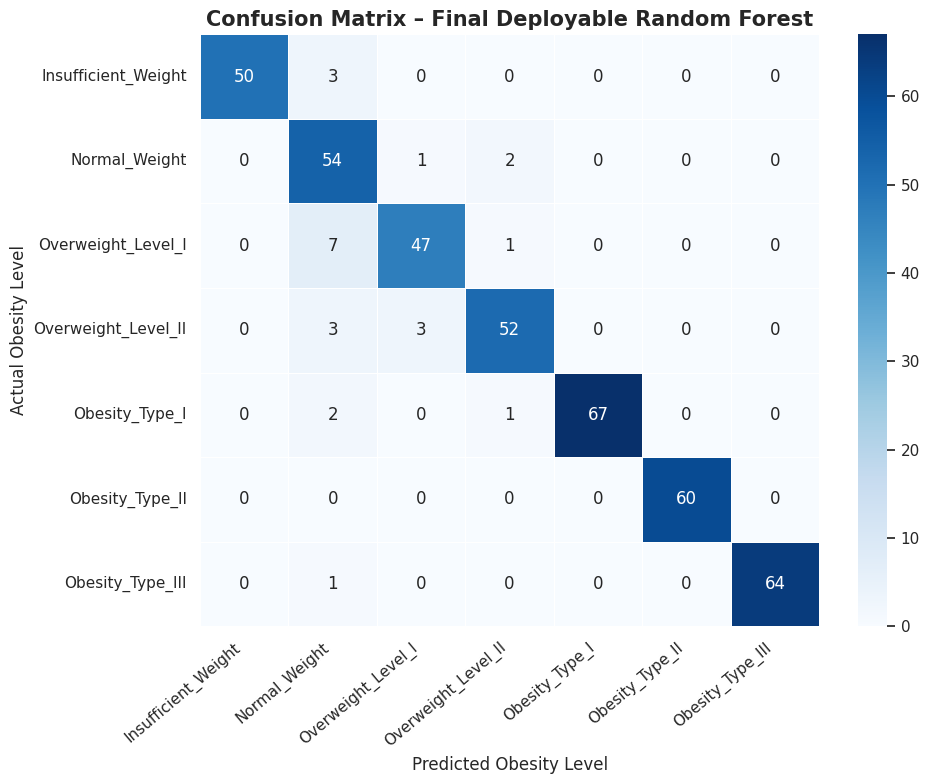

In [32]:
final_cm = confusion_matrix(
    y_test_proposal,
    final_y_pred,
    labels=class_order
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
    linewidths=0.5
)

plt.title(
    "Confusion Matrix – Final Deployable Random Forest",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Predicted Obesity Level")
plt.ylabel("Actual Obesity Level")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
final_model_classes = (
    final_deployable_model
    .named_steps["classifier"]
    .classes_
)

final_probabilities = (
    final_deployable_model.predict_proba(
        X_test_proposal
    )
)

final_y_test_binary = label_binarize(
    y_test_proposal,
    classes=final_model_classes
)

final_macro_auc = roc_auc_score(
    final_y_test_binary,
    final_probabilities,
    average="macro",
    multi_class="ovr"
)

final_class_auc = {}

for index, class_name in enumerate(final_model_classes):
    final_class_auc[class_name] = roc_auc_score(
        final_y_test_binary[:, index],
        final_probabilities[:, index]
    )

final_auc_table = pd.DataFrame({
    "Obesity Class": final_class_auc.keys(),
    "ROC-AUC": final_class_auc.values()
})

final_auc_table["ROC-AUC"] = (
    final_auc_table["ROC-AUC"].round(4)
)

print(
    "Final Macro ROC-AUC:",
    round(final_macro_auc, 4)
)

final_auc_table.sort_values(
    "ROC-AUC",
    ascending=False
)

Final Macro ROC-AUC: 0.9955


,Obesity Class,ROC-AUC
3,Obesity_Type_II,1.0000
4,Obesity_Type_III,1.0000
0,Insufficient_Weight,0.9998
2,Obesity_Type_I,0.9989
6,Overweight_Level_II,0.9912
5,Overweight_Level_I,0.9900
1,Normal_Weight,0.9883


In [34]:
final_preprocessor = (
    final_deployable_model
    .named_steps["preprocessor"]
)

final_classifier = (
    final_deployable_model
    .named_steps["classifier"]
)

final_feature_names = (
    final_preprocessor.get_feature_names_out()
)

final_importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_classifier.feature_importances_
})

final_importance_df["Feature"] = (
    final_importance_df["Feature"]
    .str.replace("continuous__", "", regex=False)
    .str.replace("ordinal_numeric__", "", regex=False)
    .str.replace("binary__", "", regex=False)
    .str.replace("nominal__", "", regex=False)
)

final_importance_df = final_importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

final_importance_df["Importance (%)"] = (
    final_importance_df["Importance"] * 100
).round(2)

final_importance_df.head(15)

,Feature,Importance,Importance (%)
0,Weight,0.291955,29.20
1,Age,0.093642,9.36
2,Height,0.085474,8.55
3,FCVC,0.079356,7.94
4,Gender,0.053632,5.36
5,NCP,0.047985,4.80
6,FAF,0.044156,4.42
7,TUE,0.043361,4.34
8,CH2O,0.043052,4.31
9,Physical_Activity_Score,0.040814,4.08


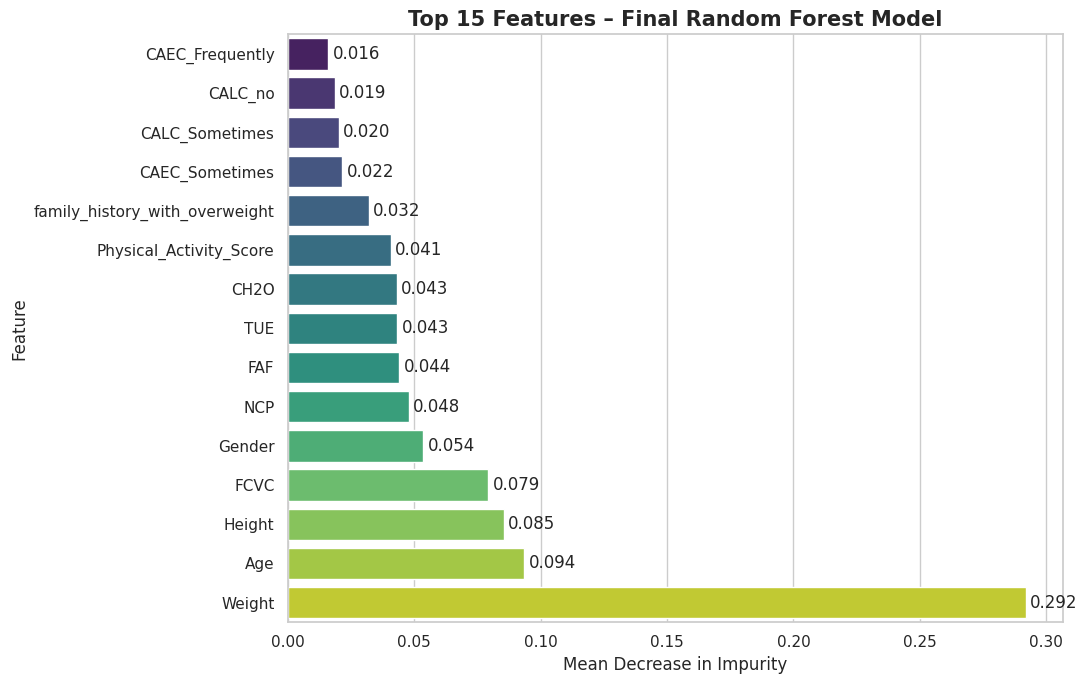

In [35]:
final_top_features = (
    final_importance_df
    .head(15)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=final_top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 15 Features – Final Random Forest Model",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Mean Decrease in Impurity")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [36]:
final_sample_patient = pd.DataFrame([{
    "Age": 30,
    "Gender": "Male",
    "Height": 1.75,
    "Weight": 95,
    "CALC": "Sometimes",
    "FAVC": "yes",
    "FCVC": 2,
    "NCP": 3,
    "SCC": "no",
    "SMOKE": "no",
    "CH2O": 2,
    "family_history_with_overweight": "yes",
    "FAF": 1,
    "TUE": 1,
    "CAEC": "Sometimes",
    "MTRANS": "Public_Transportation",
    "Physical_Activity_Score": 1 - 1
}])

final_sample_prediction = (
    final_deployable_model.predict(
        final_sample_patient
    )[0]
)

final_sample_probability = (
    final_deployable_model.predict_proba(
        final_sample_patient
    )[0]
)

final_sample_confidence = (
    final_sample_probability.max() * 100
)

final_sample_bmi = (
    final_sample_patient.loc[0, "Weight"] /
    final_sample_patient.loc[0, "Height"] ** 2
)

print("FINAL SAMPLE PREDICTION")
print("=" * 40)
print("Predicted class:", final_sample_prediction)
print(f"Confidence: {final_sample_confidence:.2f}%")
print(f"BMI: {final_sample_bmi:.2f}")

FINAL SAMPLE PREDICTION
Predicted class: Overweight_Level_II
Confidence: 59.33%
BMI: 31.02


In [37]:
final_model_file = (
    "final_obesity_random_forest_pipeline.joblib"
)

joblib.dump(
    final_deployable_model,
    final_model_file
)

reloaded_final_model = joblib.load(
    final_model_file
)

reloaded_prediction = reloaded_final_model.predict(
    final_sample_patient
)[0]

print("Final model saved:", final_model_file)
print("Reloaded prediction:", reloaded_prediction)

if reloaded_prediction == final_sample_prediction:
    print("Final model verification successful!")
else:
    print("Final model verification failed!")

Final model saved: final_obesity_random_forest_pipeline.joblib
Reloaded prediction: Overweight_Level_II
Final model verification successful!


In [38]:
files.download(
    "final_obesity_random_forest_pipeline.joblib"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>